In [75]:
import torch
import torch.nn as nn
import numpy as np

import matplotlib.pyplot as plt 
import matplotlib_inline.backend_inline 

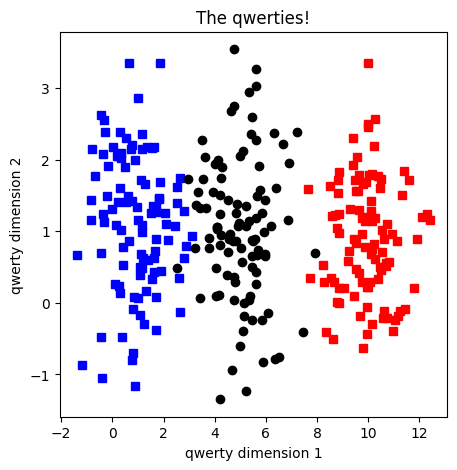

In [76]:
nPerClust = 100
blur = 1

A = [1,1]
B = [5,1]
C = [10,1]

a = [A[0]+np.random.randn(nPerClust)*blur, A[1]+np.random.randn(nPerClust)*blur]
b = [B[0]+np.random.randn(nPerClust)*blur, B[1]+np.random.randn(nPerClust)*blur]
c = [C[0]+np.random.randn(nPerClust)*blur, C[1]+np.random.randn(nPerClust)*blur]

labels_np = np.vstack((np.zeros((nPerClust,1)),np.ones((nPerClust,1)), np.ones((nPerClust,1))*2))

data_np = np.hstack((a,b,c)).T
data = torch.tensor(data_np).float()
labels = torch.tensor(labels_np).long().squeeze()

fig = plt.figure(figsize=(5,5))
plt.plot(data[np.where(labels==0)[0],0],data[np.where(labels==0)[0],1],'bs')
plt.plot(data[np.where(labels==1)[0],0],data[np.where(labels==1)[0],1],'ko')
plt.plot(data[np.where(labels==2)[0],0],data[np.where(labels==2)[0],1],'rs')
plt.title('The qwerties!')
plt.xlabel('qwerty dimension 1')
plt.ylabel('qwerty dimension 2')
plt.show()

In [77]:
ANNClassify = nn.Sequential(
    nn.Linear(2,4),
    nn.ReLU(),
    nn.Linear(4,3),
    # nn.Softmax(dim=1)
)

lossfun = nn.CrossEntropyLoss()
learningRate = .01
optimizer = torch.optim.SGD(ANNClassify.parameters(), lr=learningRate)

yHat = ANNClassify(data)
print(data.shape)
print(yHat.shape)
labels.shape

torch.Size([300, 2])
torch.Size([300, 3])


torch.Size([300])

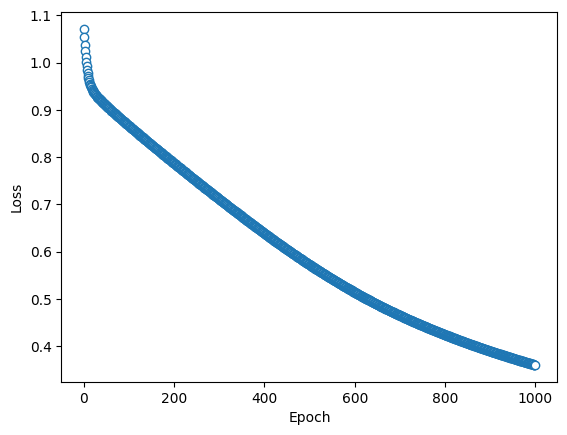

In [78]:
numepochs = 1000
losses = torch.zeros(numepochs)

for epochi in range(numepochs):
    yHat = ANNClassify(data)

    loss = lossfun(yHat, labels)
    losses[epochi] = loss 

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

plt.plot(losses.detach(),'o',markerfacecolor='w',linewidth=.1)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()



In [79]:
predictions=ANNClassify(data)

predlabels=torch.argmax(predictions,axis=1)
totalacc=100*torch.mean((predlabels==labels).float())
totalacc

tensor(94.6667)